<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab%2016/Lab_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
!pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [20]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7255, 7)
Download successful ✓


In [11]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7255, 7)
Download successful ✓


In [12]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [13]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [14]:
# ============================================================
# PART 1D: OLS Baseline — Demonstrating the Failure Mode
# ============================================================

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.600
Test R²:      -0.849

Training MSE: 2.640
Test MSE:     8.252

Gap (Train R² - Test R²): 1.449

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


In [15]:
# ============================================================
# PART 2A: Ridge Regression with Cross-Validated Lambda
# ============================================================

# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)  # ← complete this line

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)  # ← complete this line

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.051
Test MSE:                 4.691

vs. OLS: Test R² = -0.849, Test MSE = 8.252


In [16]:
# ============================================================
# PART 2B: LassoCV — Automated Feature Selection
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter
    and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray — Standardized training features
    y_train : np.ndarray — Training outcome (GDP growth)
    X_test  : np.ndarray — Standardized test features
    y_test  : np.ndarray — Test outcome
    cv      : int — Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV — Fitted model with optimal alpha
    test_r2     : float   — R² on held-out test set
    test_mse    : float   — MSE on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0656
Non-zero coefficients:    17 of 28
Test R²:                  -0.330
Test MSE:                 5.934

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0240
  population_growth                        coef = -0.7706
  natural_resource_rents_pct_gdp           coef = -0.6521
  health_expenditure_pct_gdp               coef = -0.4145
  infant_mortality_per1000                 coef = -0.3856
  atms_per100k                             coef = -0.3850
  unemployment_rate                        coef = -0.3716
  renewable_energy_pct                     coef = +0.3627
  urbanization_pct                         coef = -0.3546
  exchange_rate_official                   coef = +0.3112
  arable_land_pct                          coef = +0.1881
  tertiary_enrollment_gross                coef = -0.0797
  mobile_subscriptions_per100              coef = +0.0729
  private_credit_pct_gdp            

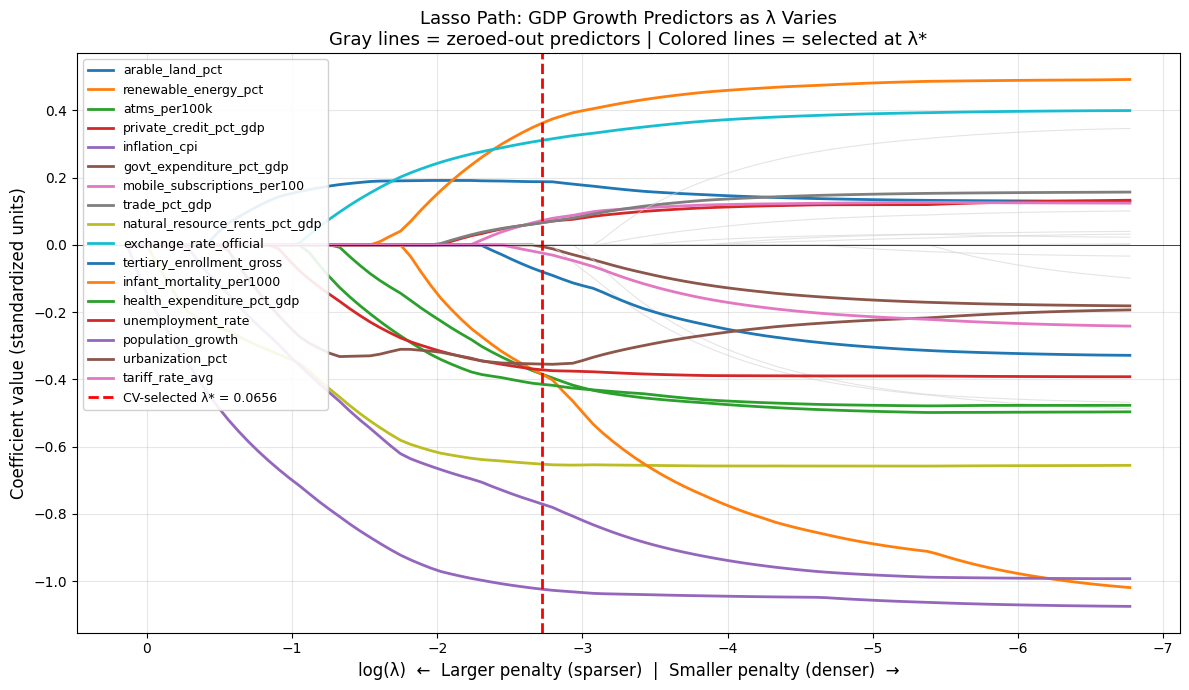

Lasso Path saved to lasso_path_gdp_growth.png


In [17]:
# ============================================================
# PART 2C: The Lasso Path — Who Enters First?
# ============================================================

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,
    n_alphas=100,
)

optimal_alpha = lasso_cv_model.alpha_

fig, ax = plt.subplots(figsize=(12, 7))

active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

In [18]:
# ============================================================
# PART 2D: Model Comparison Table
# ============================================================

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],
        X_train.shape[1],
        np.sum(lasso_cv_model.coef_ != 0)
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • The other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   28       0.600  -0.849    8.252
Ridge (RidgeCV)          47.1487                   28       0.557  -0.051    4.691
Lasso (LassoCV)           0.0656                   17       0.569  -0.330    5.934

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 17 of 28 predictors
  • The other 11 are predictively redundant,
    not necessarily economically unimportant


My colleague is incorrect because Lasso zeros show conditional predictive redundancy, not economic irrelevance. If paved roads pct is highly correlated with other development variables, it could be dropped due to correlation structure, but not because it does not matter. This also does not help us understand the casual relationship with GDP growth.

For this specific dataset, ridge would be preferred because the predictors are highly correlated. Ridge also showed a lower test MSE and higher r^2, so it outperformed Lasso.

In [21]:
# ============================================================
# INTERACTIVE PLOTLY DASHBOARD: Lasso Path + Coefficient Comparison
# Assumes these objects exist in your notebook:
#   X_train_scaled  : np.ndarray, shape (n_train, n_features)
#   y_train         : np.ndarray, shape (n_train,)
#   feature_names   : list of str, length n_features
#   ols_model       : fitted sklearn LinearRegression
#   ridge_cv        : fitted sklearn RidgeCV
#   lasso_cv        : fitted sklearn LassoCV
# ============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import lasso_path, LinearRegression, RidgeCV, LassoCV
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ─── 1. LASSO PATH COMPUTATION ───────────────────────────────────────────────
# lasso_path() returns (alphas, coefs, dual_gaps).
# alphas: decreasing sequence of λ values tried
# coefs : shape (n_features, n_alphas) — coefficient matrix along the path
# We set eps=1e-4 so the path runs from λ_max down to λ_max * 1e-4
# n_alphas=200 gives smooth curves; fit_intercept=False because X is already scaled
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-4, n_alphas=200
)

# log10 transform for a readable slider scale (λ spans several orders of magnitude)
log_alphas = np.log10(alphas_path)

# ─── 2. COEFFICIENT EXTRACTION ───────────────────────────────────────────────
# Each model stores its coefficients in .coef_ after fitting.
# RidgeCV and LassoCV also expose .alpha_ (the best λ found by CV).

ols_coefs   = ols_model.coef_           # shape (n_features,)
ridge_coefs = ridge_cv.coef_            # shape (n_features,)
lasso_coefs = lasso_cv_model.coef_            # shape (n_features,); sparse — many zeros

best_ridge_alpha = ridge_cv.alpha_      # scalar — the CV-selected λ for Ridge
best_lasso_alpha = lasso_cv_model.alpha_      # scalar — the CV-selected λ for Lasso

print(f"Ridge best λ: {best_ridge_alpha:.4f}")
print(f"Lasso best λ: {best_lasso_alpha:.4f}")
print(f"Lasso non-zero features: {np.sum(lasso_coefs != 0)}/{len(feature_names)}")

# ─── 3. R² ALONG THE LASSO PATH ──────────────────────────────────────────────
# For each α on the path, refit a Lasso with that fixed α and score on train set.
# NOTE: training R² will always decrease as λ increases (more shrinkage).
# This is intentional — we show it so the user can see the bias-variance tradeoff.
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

r2_path = []
for alpha in alphas_path:
    lasso_tmp = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)
    lasso_tmp.fit(X_train_scaled, y_train)
    r2_path.append(r2_score(y_train, lasso_tmp.predict(X_train_scaled)))

r2_path = np.array(r2_path)  # shape (n_alphas,)

# ─── 4. BUILD SUBPLOT LAYOUT ─────────────────────────────────────────────────
# make_subplots creates a figure with a shared coordinate system.
# rows=1, cols=2 → side-by-side panels in a single row.
# subplot_titles label each panel.
# horizontal_spacing controls the gap (fraction of total width) between panels.
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "Lasso path — coefficient trajectories vs log(λ)",
        "Coefficient magnitudes: OLS vs Ridge vs Lasso"
    ],
    horizontal_spacing=0.12
)

# ─── 5. PANEL 1 — LASSO PATH TRACES ─────────────────────────────────────────
# Each feature gets one Scatter trace: x = log10(λ), y = coefficient value.
# All traces start visible=True; the slider callback toggles opacity, not visibility,
# so Plotly doesn't re-render the DOM — this keeps the slider responsive.

# Color palette — cycle through these for visual distinction
COLORS = [
    "#636EFA","#EF553B","#00CC96","#AB63FA","#FFA15A",
    "#19D3F3","#FF6692","#B6E880","#FF97FF","#FECB52"
]

for i, feat in enumerate(feature_names):
    fig.add_trace(
        go.Scatter(
            x=log_alphas,
            y=coefs_path[i],
            mode="lines",
            name=feat,
            line=dict(color=COLORS[i % len(COLORS)], width=1.5),
            opacity=0.4,           # default: dimmed; slider will highlight
            hovertemplate=(
                f"<b>{feat}</b><br>"
                "log(λ): %{x:.3f}<br>"
                "Coefficient: %{y:.4f}<extra></extra>"
            ),
        ),
        row=1, col=1
    )

# ─── 6. PANEL 1 — VERTICAL λ INDICATOR LINE ──────────────────────────────────
# A VLine (shape) at the current slider position marks the selected λ.
# Plotly shapes attached to a specific xref/yref move with the axis,
# but we update their x0/x1 via layout.shapes in each slider step.
# Initial position = log10(best_lasso_alpha) — the CV-optimal λ.
init_log_alpha = np.log10(best_lasso_alpha)
# Find the index in alphas_path closest to best_lasso_alpha for initial display
init_idx = np.argmin(np.abs(alphas_path - best_lasso_alpha))

fig.add_vline(
    x=init_log_alpha,
    line=dict(color="black", width=1.5, dash="dash"),
    row=1, col=1,
    annotation_text=f"CV λ = {best_lasso_alpha:.4f}",
    annotation_position="top right",
    annotation_font_size=10
)

# ─── 7. PANEL 2 — GROUPED BAR CHART ──────────────────────────────────────────
# Three Bar traces, one per model. Plotly automatically groups them by
# setting barmode="group" on the layout. The x-axis is feature_names,
# and the y-axis is the absolute coefficient value (|β|) for fair comparison
# since OLS can have large magnitudes that obscure Ridge/Lasso.

for model_name, coefs, color in [
    ("OLS",   np.abs(ols_coefs),   "#636EFA"),
    ("Ridge", np.abs(ridge_coefs), "#EF553B"),
    ("Lasso", np.abs(lasso_coefs), "#00CC96"),
]:
    fig.add_trace(
        go.Bar(
            name=model_name,
            x=feature_names,
            y=coefs,
            marker_color=color,
            opacity=0.85,
            hovertemplate=(
                f"<b>{model_name}</b><br>"
                "%{x}<br>"
                "|β|: %{y:.4f}<extra></extra>"
            ),
        ),
        row=1, col=2
    )

# ─── 8. PLOTLY SLIDER MECHANICS ──────────────────────────────────────────────
# A Plotly slider works by pre-computing one "step" object per slider position.
# Each step stores a list of "restyle" or "relayout" commands that Plotly
# executes when the user drags to that position — no Python callbacks needed
# (this is pure client-side JavaScript inside the Plotly bundle).
#
# Structure of a slider step:
#   step["args"] = [
#       {<trace_update_dict>},   # first arg: data updates (restyle)
#       [<trace_indices>]        # second arg: which traces to update
#   ]
# OR for layout-only updates:
#   step["args"] = [{}, {"shapes[0].x0": val, "shapes[0].x1": val, ...}]
#
# We use a COMBINED update (Plotly "update" method) to simultaneously:
#   (a) change trace opacities — highlight features that are non-zero at this λ
#   (b) move the vertical dashed line to the current λ
#   (c) update the R² annotation in the plot title area
#
# Slider steps correspond 1-to-1 with entries in alphas_path (n_alphas=200).
# We subsample to every 4th alpha for a snappier slider (50 positions).

STEP_EVERY = 4
slider_steps = []

n_features = len(feature_names)

for step_i, path_i in enumerate(range(0, len(alphas_path), STEP_EVERY)):
    alpha_val = alphas_path[path_i]
    log_a     = log_alphas[path_i]
    coef_vec  = coefs_path[:, path_i]   # (n_features,) coefficients at this λ
    r2_val    = r2_path[path_i]

    # Determine which features are non-zero at this λ
    # We use a small threshold (1e-4) rather than exact zero due to floating point
    active_mask = np.abs(coef_vec) > 1e-4
    n_active    = int(active_mask.sum())

    # Build opacity list: 1.0 for active features, 0.15 for zero/shrunk features
    # len(opacities) must equal the number of Panel 1 traces = n_features
    opacities = [1.0 if active_mask[i] else 0.15 for i in range(n_features)]

    # Panel 2 (bar chart) traces are indices n_features, n_features+1, n_features+2
    # We leave them at full opacity — they don't change with λ
    # Total traces in fig = n_features (path lines) + 3 (bar groups)
    bar_opacities = [0.85, 0.85, 0.85]

    all_opacities = opacities + bar_opacities

    # Each slider step fires two simultaneous Plotly commands:
    #   "restyle": update opacity on all traces
    #   "relayout": move the vline and update subtitle with current R² / active count
    step = {
        "label": f"{log_a:.2f}",         # label shown on the slider tick
        "method": "update",              # "update" = restyle + relayout combined
        "args": [
            # --- restyle payload ---
            # keys are trace properties; values are lists (one entry per trace)
            {"opacity": all_opacities},
            # --- relayout payload ---
            # shapes[0] is the vline we added with add_vline() — update x position
            {
                "shapes[0].x0": log_a,
                "shapes[0].x1": log_a,
                "shapes[0].line.color": "crimson" if path_i == init_idx else "black",
                # Dynamic annotation in the subplot title (col 1)
                # annotations[2] is the vline annotation (0 and 1 are subplot titles)
                "annotations[2].x": log_a,
                "annotations[2].text": (
                    f"λ={alpha_val:.4f} | R²={r2_val:.3f} | "
                    f"active={n_active}/{n_features}"
                ),
            }
        ]
    }
    slider_steps.append(step)

# ─── 9. ATTACH SLIDER TO FIGURE LAYOUT ───────────────────────────────────────
# The sliders list in layout can hold multiple sliders; we use just one.
# currentvalue shows the current slider label above the handle.
# pad.t adds space between the chart area and the slider track.

fig.update_layout(
    sliders=[{
        "active": 0,                          # which step is selected on load
        "steps": slider_steps,
        "x": 0.0,                             # left edge of slider (fraction)
        "len": 0.48,                          # width of slider (fraction) — only Panel 1 width
        "y": -0.15,                           # vertical position below the plot
        "xanchor": "left",
        "yanchor": "top",
        "currentvalue": {
            "prefix": "log₁₀(λ) = ",
            "font": {"size": 12},
            "visible": True,
            "xanchor": "center",
            "offset": 20,
        },
        "transition": {"duration": 50, "easing": "cubic-in-out"},
        "tickcolor": "gray",
        "bordercolor": "gray",
        "bgcolor": "lightgray",
    }]
)

# ─── 10. AXIS & LAYOUT POLISH ─────────────────────────────────────────────────

fig.update_xaxes(title_text="log₁₀(λ)", row=1, col=1, showgrid=True, gridcolor="#ececec")
fig.update_yaxes(title_text="Coefficient value", row=1, col=1,
                 zeroline=True, zerolinecolor="black", zerolinewidth=1)

fig.update_xaxes(title_text="Feature", row=1, col=2,
                 tickangle=45, tickfont=dict(size=9))
fig.update_yaxes(title_text="|Coefficient|", row=1, col=2)

fig.update_layout(
    title=dict(
        text=(
            "Regularization Explorer — World Development Indicators<br>"
            "<sup>Drag slider (Panel 1) to change λ and highlight active predictors</sup>"
        ),
        font=dict(size=15),
        x=0.5,
        xanchor="center",
    ),
    barmode="group",          # grouped (side-by-side) bars in Panel 2
    legend=dict(
        title="Feature / Model",
        font=dict(size=9),
        itemsizing="constant",
        x=1.01,
        y=1,
        xanchor="left",
    ),
    height=580,
    margin=dict(l=60, r=180, t=100, b=130),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial, sans-serif", size=11, color="#333"),
    hoverlabel=dict(bgcolor="white", font_size=11),
)

# ─── 11. ADD REFERENCE LINES IN PANEL 1 ──────────────────────────────────────
# Vertical line at the CV-optimal Ridge α (for comparison)
fig.add_vline(
    x=np.log10(best_ridge_alpha),
    line=dict(color="tomato", width=1.2, dash="dot"),
    row=1, col=1,
    annotation_text=f"Ridge λ* = {best_ridge_alpha:.3f}",
    annotation_position="bottom right",
    annotation_font_size=9,
    annotation_font_color="tomato",
)

fig.show()

# Optional: export as standalone HTML (no server needed)
fig.write_html("regularization_dashboard.html", include_plotlyjs="cdn")
print("Dashboard saved → regularization_dashboard.html")

Ridge best λ: 47.1487
Lasso best λ: 0.0656
Lasso non-zero features: 17/28


Dashboard saved → regularization_dashboard.html
